### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import lightgbm as lgb
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
import math
import warnings
warnings.filterwarnings('ignore')

DATA_DIR  = '../data/raw/'
TRAIN_FILE = DATA_DIR + 'sales.csv'
TEST_FILE   = DATA_DIR + 'sample_submission.csv'

### Load Data

In [2]:
train = pd.read_csv(TRAIN_FILE, parse_dates=['Date'])
test  = pd.read_csv(TEST_FILE,  parse_dates=['Date'])

test = test.drop(columns=['Revenue', 'COGS'])
promotions = pd.read_csv(DATA_DIR + "promotions.csv", parse_dates=["start_date", "end_date"])

### Data Boundaries

In [3]:
print("--- DATE BOUNDARIES ---")
print(f"Train Period: {train['Date'].min().date()} to {train['Date'].max().date()}")
print(f"Test Period : {test['Date'].min().date()} to {test['Date'].max().date()}")



print("\n--- BASELINE REVENUE STATS ---")
print(train[["Revenue", "COGS"]].describe().round(2))

--- DATE BOUNDARIES ---
Train Period: 2012-07-04 to 2022-12-31
Test Period : 2023-01-01 to 2024-07-01

--- BASELINE REVENUE STATS ---
           Revenue         COGS
count      3833.00      3833.00
mean    4286584.03   3695134.49
std     2624840.20   2219788.77
min      279813.94    236576.31
25%     2471088.82   2150580.23
50%     3647303.90   3161112.99
75%     5350877.20   4637293.92
max    20905271.35  16535857.67


### Feature Engineering

**Date feature**

In [4]:
def apply_advanced_features(df, tet_dates):
    df = df.copy()
    
    # 1. Basic time variables
    df["day_of_week"] = df["Date"].dt.dayofweek
    df["day_of_month"] = df["Date"].dt.day
    df["day_of_year"] = df["Date"].dt.dayofyear
    df["month"] = df["Date"].dt.month
    df["year"] = df["Date"].dt.year
    
    # 2. Behavioral features
    df["is_weekend"] = np.where(df["day_of_week"] >= 5, 1, 0)
    # Payday window (from 25th of this month to 5th of next month)
    df["is_payday_window"] = np.where((df["day_of_month"] >= 1) | (df["day_of_month"] <= 15), 1, 0)
    # Double days (1/1, 2/2...)
    df["is_double_day"] = np.where(df["month"] == df["day_of_month"], 1, 0)
    # Time trend
    df["days_since_start"] = (df["Date"] - df["Date"].min()).dt.days

    # 3. Lunar New Year date logic
    # Convert dict to Series to map by year
    tet_series = pd.to_datetime(pd.Series(tet_dates))
    
    def calculate_dist_to_tet(row):
        current_year = row['Date'].year
        tet_date = tet_series.get(current_year)
        if tet_date:
            return (row['Date'] - tet_date).days
        return 0

    # Calculate distance to Lunar New Year (Negative = before Tet, Positive = after Tet)
    df['days_to_tet'] = df.apply(calculate_dist_to_tet, axis=1)
    
    # Create "Lunar New Year season" variable (Example: 15 days before Tet and 7 days after Tet)
    df['is_tet_season'] = np.where((df['days_to_tet'] >= -15) & (df['days_to_tet'] <= 7), 1, 0)

    return df

# List of Lunar New Year dates
tet_dates = {
    2012: "2012-01-23", 2013: "2013-02-10", 2014: "2014-01-31", 2015: "2015-02-19",
    2016: "2016-02-08", 2017: "2017-01-28", 2018: "2018-02-16", 2019: "2019-02-05",
    2020: "2020-01-25", 2021: "2021-02-12", 2022: "2022-02-01", 2023: "2023-01-22",
    2024: "2024-02-10"
}

# Apply to train and test sets
train = apply_advanced_features(train, tet_dates)
test = apply_advanced_features(test, tet_dates)

**Promotion feature**

In [5]:
promo_daily = []
for _, row in promotions.iterrows():
    days = pd.date_range(row['start_date'], row['end_date'])
    for d in days:
        promo_daily.append({
            'Date': d,
            'promo_id' : row['promo_id'],
            'promo_type': row['promo_type'],
            'discount': row['discount_value'],
            'is_stackable': row['stackable_flag'],
            'min_value': row['min_order_value']
        })

promo_df_expanded = pd.DataFrame(promo_daily)

In [6]:
promo_daily_summary = promo_df_expanded.groupby('Date').agg({
    'promo_id': 'count',               # Total number of programs running in the day
    'discount': 'max',                 # Maximum discount that can be received
    'min_value': 'mean',               # Average minimum order value
    'is_stackable': 'max',             # Is there any program that allows stacking (1/0)
}).rename(columns={'promo_id': 'promo_count'}).reset_index()

# Create additional simple binary column
promo_daily_summary['is_promo'] = 1

In [7]:
# Merge into Train set
train = train.merge(promo_daily_summary, on='Date', how='left')

# Tạo thêm cột tháng và ngày từ promo_daily_summary
promo_daily_summary['month'] = promo_daily_summary['Date'].dt.month
promo_daily_summary['day'] = promo_daily_summary['Date'].dt.day

# Tạo bảng tra cứu: Tính trung bình (hoặc Max) các chỉ số theo Tháng/Ngày
# Bước này giúp xử lý nếu một ngày có nhiều năm dữ liệu (ví dụ 01/01/2024 và 01/01/2025)
seasonal_lookup = promo_daily_summary.groupby(['month', 'day']).agg({
    'promo_count': 'max',
    'discount': 'max',
    'min_value': 'mean',
    'is_stackable': 'max',
    'is_promo': 'max'
}).reset_index()

test['month'] = test['Date'].dt.month
test['day'] = test['Date'].dt.day

# Merge dựa trên Month/Day thay vì Date
test = test.merge(seasonal_lookup, on=['month', 'day'], how='left')

# Important: Days without promotions will be NaN, fill with 0
cols_to_fill = ['promo_count', 'discount', 'min_value', 'is_stackable', 'is_promo']
train[cols_to_fill] = train[cols_to_fill].fillna(0)
test[cols_to_fill] = test[cols_to_fill].fillna(0)

In [8]:
# def add_peak_features(df):
#     df = df.copy()
    
#     # 1. Rolling Max (An toàn)
#     df['rev_rolling_max_7'] = df['Revenue'].shift(1).rolling(window=7).max()
    
#     # 2. Đặc trưng Double Day Impact (Sửa lỗi KeyError)
#     # Khởi tạo cột bằng 0 trước để cột luôn tồn tại
#     df['expected_double_day_impact'] = 0.0
    
#     # Kiểm tra xem có ngày Double Day nào trong dữ liệu không
#     is_dd = df['is_double_day'] == 1
#     if is_dd.any():
#         double_days = df[is_dd].copy()
#         # Tính toán giá trị impact
#         impact = double_days['Revenue'].shift(1).expanding().mean()
        
#         # Gán giá trị vào đúng những ngày Double Day, những ngày khác vẫn là 0.0
#         # Dùng .loc sẽ an toàn hơn merge trong trường hợp này
#         df.loc[is_dd, 'expected_double_day_impact'] = impact
    
#     # 3. Độ dốc doanh thu (Momentum)
#     df['rev_velocity'] = df['Revenue'].shift(1) / df['Revenue'].shift(2)
    
#     # Xử lý giá trị vô cùng (inf) nếu có và fill các giá trị NaN còn lại
#     df = df.replace([np.inf, -np.inf], 0)
#     return df.fillna(0)

In [9]:
# # --- BƯỚC 1: Xử lý cho tập TRAIN ---
# train = add_peak_features(train)

# # --- BƯỚC 2: Xử lý cho tập TEST (Sử dụng kỹ thuật Buffer) ---
# # Lấy 7 ngày cuối của train làm buffer
# train_buffer = train.tail(7).copy()

# # Gộp buffer vào trước tập test
# test_with_buffer = pd.concat([train_buffer, test], axis=0).reset_index(drop=True)

# # Tính toán đặc trưng trên bảng gộp (đã có Revenue từ buffer)
# test_featured = add_peak_features(test_with_buffer)

# # Tách lại tập Test (bỏ 7 dòng buffer)
# # Sau bước này, 'test' đã có đầy đủ features rồi, KHÔNG gọi add_peak_features lần nữa.
# test = test_featured.iloc[7:].copy().reset_index(drop=True)

In [10]:
test.to_csv("test.csv", index=False)

In [11]:
test.columns

Index(['Date', 'day_of_week', 'day_of_month', 'day_of_year', 'month', 'year',
       'is_weekend', 'is_payday_window', 'is_double_day', 'days_since_start',
       'days_to_tet', 'is_tet_season', 'day', 'promo_count', 'discount',
       'min_value', 'is_stackable', 'is_promo'],
      dtype='str')

### Train Model

**Prepare Data**

In [12]:
features = train.columns.to_list()

remove_cols = ['Date', 'Revenue', 'COGS']

features = [f for f in features if f not in remove_cols]

In [13]:
train_data = train[train['year'] < 2021]
val_data = train[train['year'] >= 2021]

X_train, y_rev_train = train_data[features], np.log1p(train_data['Revenue'])
X_val, y_rev_val = val_data[features], np.log1p(val_data['Revenue'])

y_cogs_train = np.log1p(train_data['COGS'])
y_cogs_val = np.log1p(val_data['COGS'])

weights = np.where(train_data['is_promo'] == 1, 5, 1)

print(f"Train shapes: X={X_train.shape}, y={y_rev_train.shape}")
print(f"Val shapes: X={X_val.shape}, y={y_rev_val.shape}")

Train shapes: X=(3103, 16), y=(3103,)
Val shapes: X=(730, 16), y=(730,)


In [14]:
def evaluate_model(y_true_log, y_pred_log, label="Model"):
    # 1. Đưa cả giá trị thực và dự báo về thang đo gốc (Original Scale)
    y_true = np.expm1(y_true_log)
    y_pred = np.maximum(0, np.expm1(y_pred_log))
    
    # 2. Tính toán các chỉ số
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- Evaluation {label} ---")
    print(f"MAE : {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R2  : {r2:.4f}")
    
    return mae, rmse, r2

**Train Model**

In [15]:
xgb_params = {
    "n_estimators": 1000,
    "learning_rate": 0.03,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "early_stopping_rounds" : 100,
    "random_state": 42,
    "tree_method": "hist",
    "objective" : 'reg:tweedie'
}

lgb_params = {
    'n_estimators': 1000,
    'learning_rate': 0.01,
    'max_depth': 12,
    'num_leaves': 31,            # Tham số quan trọng nhất của LightGBM
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'objective': 'regression',
    'random_state': 42,
    'verbose': -1                # Tắt các thông báo thừa
}

In [16]:
# Cấu hình mô hình XGBoost
model_rev_xgb = xgb.XGBRegressor(**xgb_params)
model_rev_lgb = lgb.LGBMRegressor(**lgb_params)

# Huấn luyện mô hình Revenue
model_rev_xgb.fit(
    X_train, y_rev_train,
    sample_weight=weights,
    eval_set=[(X_val, y_rev_val)],
    verbose=100
)

model_rev_lgb.fit(
    X_train, y_rev_train,
    sample_weight=weights,
    eval_set=[(X_val, y_rev_val)],
    eval_metric='rmse'
)

rev_preds_xgb = model_rev_xgb.predict(X_val)
rev_preds_lgb = model_rev_lgb.predict(X_val)

X_meta_train = np.column_stack((rev_preds_xgb, rev_preds_lgb))
meta_model_rev = Ridge(alpha=1.0)
meta_model_rev.fit(X_meta_train, y_rev_val)
final_stacking_preds = meta_model_rev.predict(X_meta_train)

mae_rev, rmse_rev, r2_rev = evaluate_model(y_rev_val, final_stacking_preds, "Revenue")

[0]	validation_0-tweedie-nloglik@1.5:15.37956
[100]	validation_0-tweedie-nloglik@1.5:15.37673
[200]	validation_0-tweedie-nloglik@1.5:15.37677
[205]	validation_0-tweedie-nloglik@1.5:15.37677
--- Evaluation Revenue ---
MAE : 558,531.67
RMSE: 790,943.28
R2  : 0.7749


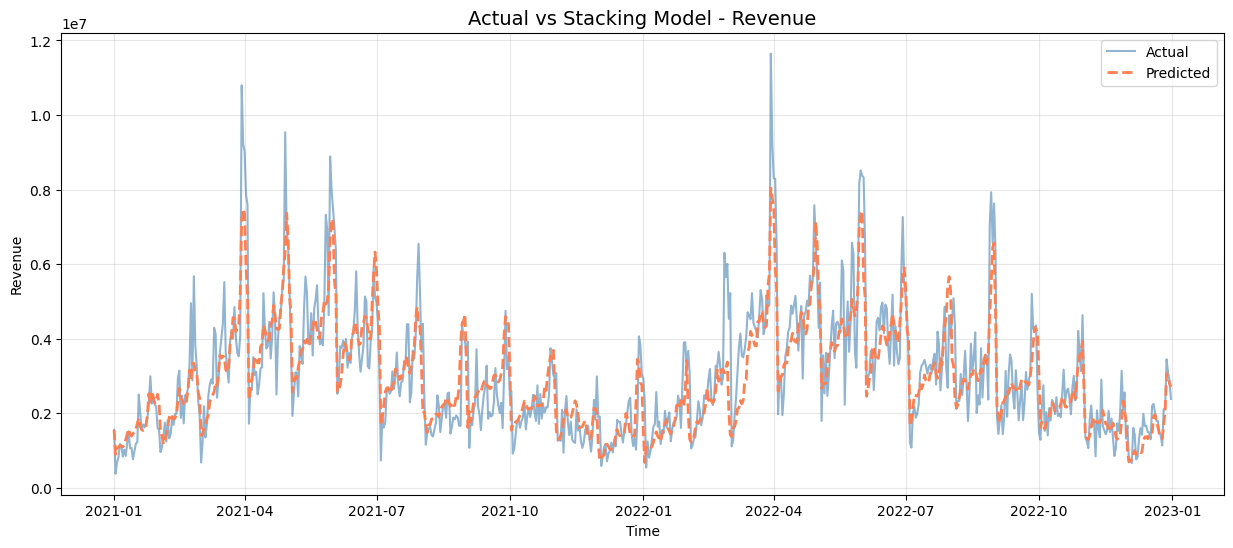

In [17]:
val_preds_xgb = model_rev_xgb.predict(X_val)
val_preds_lgb = model_rev_lgb.predict(X_val)

X_meta_val = np.column_stack((val_preds_xgb, val_preds_lgb))

final_val_log_preds = meta_model_rev.predict(X_meta_val)

plt.figure(figsize=(15, 6))

plt.plot(val_data['Date'], np.expm1(y_rev_val), 
         label='Actual', color='steelblue', alpha=0.6)

plt.plot(val_data['Date'], np.expm1(final_val_log_preds), 
         label='Predicted', color='coral', linestyle='--', linewidth=2)

plt.title("Actual vs Stacking Model - Revenue", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
model_cogs_xgb = xgb.XGBRegressor(**xgb_params)
model_cogs_lgb = lgb.LGBMRegressor(**lgb_params)

# Huấn luyện mô hình Revenue
model_cogs_xgb.fit(
    X_train, y_cogs_train,
    sample_weight=weights,
    eval_set=[(X_val, y_cogs_val)],
    verbose=100
)

model_cogs_lgb.fit(
    X_train, y_cogs_train,
    sample_weight=weights,
    eval_set=[(X_val, y_cogs_val)],
    eval_metric='rmse'
)

cogs_preds_xgb = model_cogs_xgb.predict(X_val)
cogs_preds_lgb = model_cogs_lgb.predict(X_val)

X_meta_train = np.column_stack((cogs_preds_xgb, cogs_preds_lgb))
meta_model_cogs = Ridge(alpha=1.0)
meta_model_cogs.fit(X_meta_train, y_cogs_val)
final_stacking_preds = meta_model_cogs.predict(X_meta_train)

mae_rev, rmse_rev, r2_rev = evaluate_model(y_cogs_val, final_stacking_preds, "COGS")

[0]	validation_0-tweedie-nloglik@1.5:15.31977
[100]	validation_0-tweedie-nloglik@1.5:15.31679
[200]	validation_0-tweedie-nloglik@1.5:15.31688
[201]	validation_0-tweedie-nloglik@1.5:15.31688
--- Evaluation COGS ---
MAE : 495,982.67
RMSE: 700,455.27
R2  : 0.7668


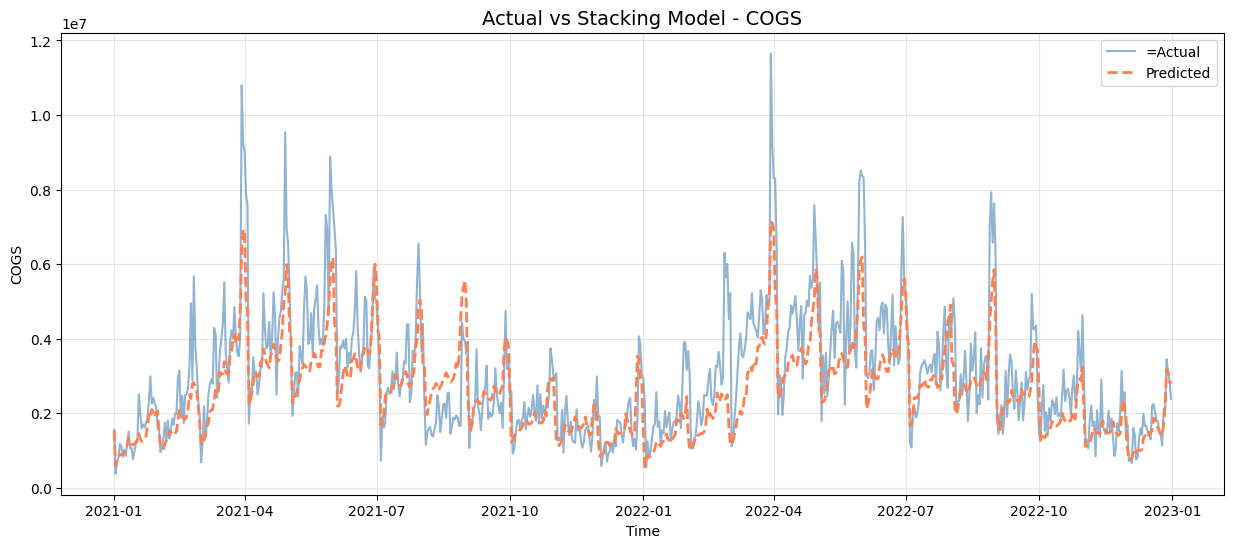

In [19]:
val_preds_xgb = model_cogs_xgb.predict(X_val)
val_preds_lgb = model_cogs_lgb.predict(X_val)

X_meta_val = np.column_stack((val_preds_xgb, val_preds_lgb))

final_val_log_preds = meta_model_cogs.predict(X_meta_val)

plt.figure(figsize=(15, 6))

plt.plot(val_data['Date'], np.expm1(y_rev_val), 
         label='=Actual', color='steelblue', alpha=0.6)

plt.plot(val_data['Date'], np.expm1(final_val_log_preds), 
         label='Predicted', color='coral', linestyle='--', linewidth=2)

plt.title("Actual vs Stacking Model - COGS", fontsize=14)
plt.xlabel("Time")
plt.ylabel("COGS")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
# Tạo 2 biểu đồ cạnh nhau để so sánh
def plot_importance(model_xgb, model_lgb):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    # 1. Soi XGBoost
    xgb.plot_importance(model_xgb, importance_type='weight', ax=ax1, max_num_features=10)
    ax1.set_title("XGBoost Importance (Weight)")

    # 2. Soi LightGBM
    lgb.plot_importance(model_lgb, importance_type='split', ax=ax2, max_num_features=10)
    ax2.set_title("LightGBM Importance (Split)")

    plt.tight_layout()
    plt.show()

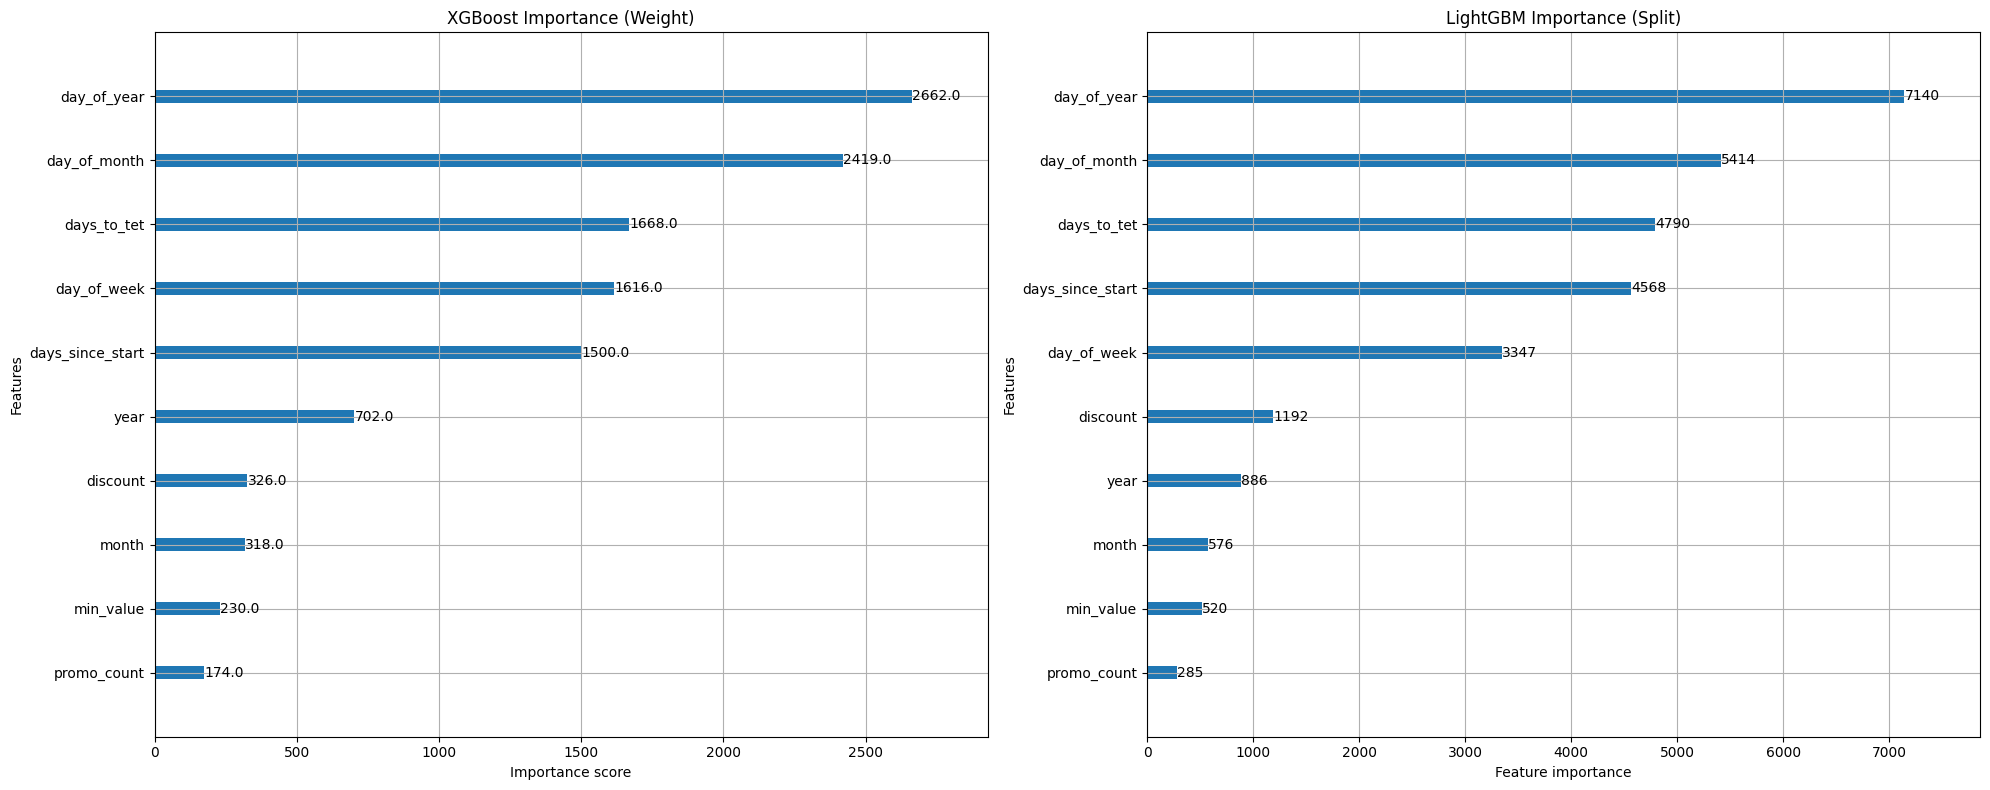

In [21]:
plot_importance(model_xgb=model_rev_xgb, model_lgb=model_rev_lgb)

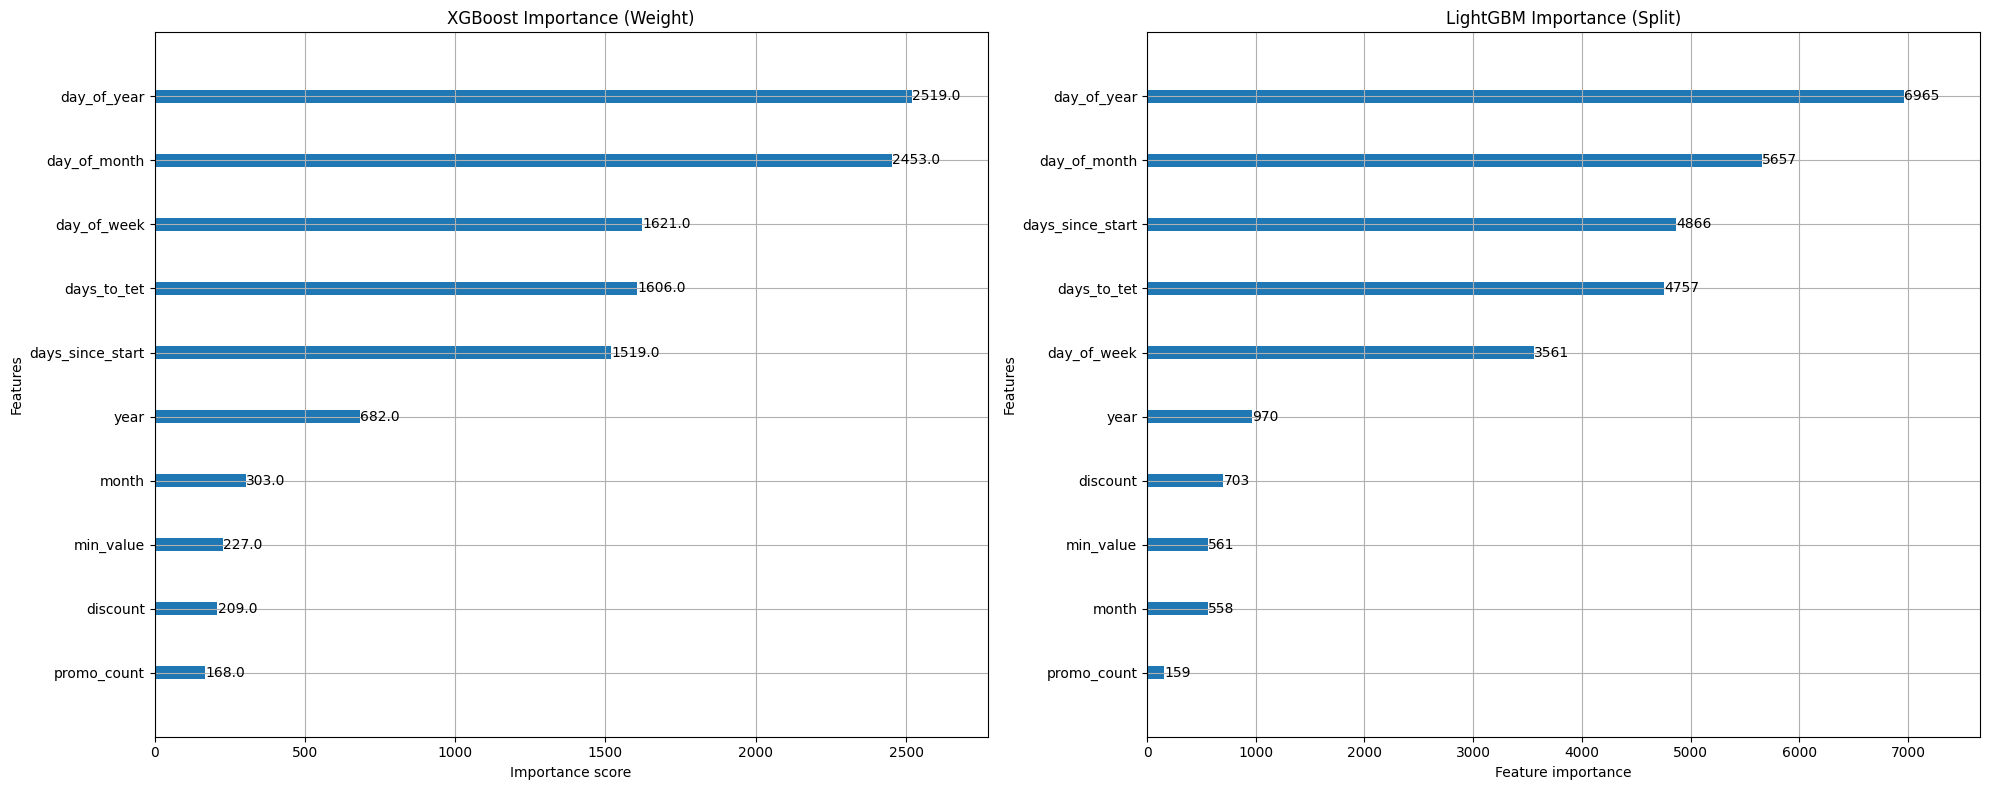

In [22]:
plot_importance(model_xgb=model_cogs_xgb, model_lgb=model_cogs_lgb)

### Save Submission

In [ ]:
def predict_stacking(X_test, model_xgb, model_lgb, meta_model):
    # Dự báo từ 2 mô hình gốc
    p_xgb = model_xgb.predict(X_test)
    p_lgb = model_lgb.predict(X_test)
    
    # Đưa qua trọng tài Meta-model
    X_meta_test = np.column_stack((p_xgb, p_lgb))
    p_stacked_log = meta_model.predict(X_meta_test)
    
    # Nghịch đảo Log về tiền thực tế
    return np.expm1(p_stacked_log)

# Sử dụng
test['Revenue'] = predict_stacking(test[features], model_rev_xgb, model_rev_lgb, meta_model_rev)
test['COGS'] = predict_stacking(test[features], model_cogs_xgb, model_cogs_lgb, meta_model_cogs)

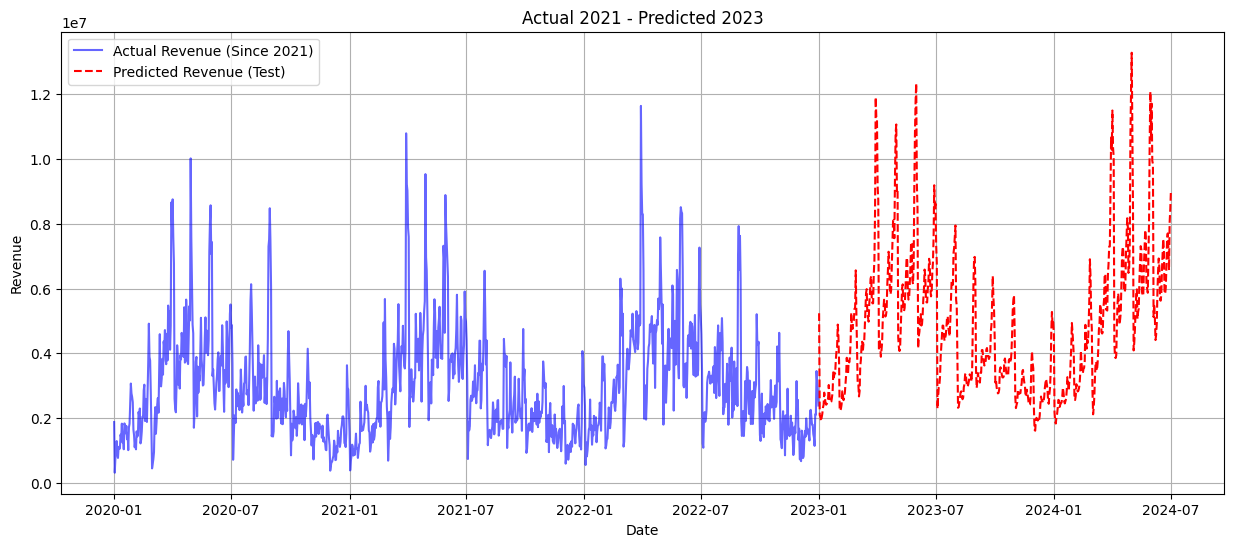

In [24]:
train_from_2021 = train[train['Date'] >= '2020-01-01']

plt.figure(figsize=(15, 6))

# 2. Vẽ dữ liệu lịch sử (Chỉ từ 2021)
plt.plot(train_from_2021['Date'], train_from_2021['Revenue'], 
         label='Actual Revenue (Since 2021)', color='blue', alpha=0.6)

# 3. Vẽ dữ liệu dự báo (Đã dùng expm1)
# Lưu ý: dùng test['Revenue_Pred'] nếu bạn đã gán biến dự báo vào đó
plt.plot(test['Date'], test['Revenue'], 
         label='Predicted Revenue (Test)', color='red', linestyle='--')

plt.title('Actual 2021 - Predicted 2023')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
submission = test[['Date', 'Revenue', 'COGS']]
submission.to_csv('submission.csv', index=False, float_format='%.2f')
print("Saved file submission.csv")

Saved file submission.csv
